# Home Assignment 2 Coding Solutions
**Student Name:** Md Shakiful Islam Khan

## Q1: Implementing an RNN for Text Generation

In [7]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Activation
from tensorflow.keras.optimizers import RMSprop

# --- Input Text Corpus ---
text = "to be or not to be that is the question whether tis nobler in the mind to suffer the slings and arrows of outrageous fortune or to take arms against a sea of troubles and by opposing end them"

# --- Character Mapping ---
# Extract unique characters and sort them to build character-to-index mappings
chars = sorted(list(set(text)))
char_indices = dict((c, i) for i, c in enumerate(chars))
indices_char = dict((i, c) for i, c in enumerate(chars))

# --- Dataset Preparation ---
# Segment the text into semi-overlapping sequences of a fixed length
maxlen = 20
step = 3
sentences = []
next_chars = []
for i in range(0, len(text) - maxlen, step):
    sentences.append(text[i: i + maxlen])
    next_chars.append(text[i + maxlen])

# --- Vectorization (One-Hot Encoding) ---
# Represent the characters as boolean matrices
x = np.zeros((len(sentences), maxlen, len(chars)), dtype=np.bool_)
y = np.zeros((len(sentences), len(chars)), dtype=np.bool_)
for i, sentence in enumerate(sentences):
    for t, char in enumerate(sentence):
        x[i, t, char_indices[char]] = 1
    y[i, char_indices[next_chars[i]]] = 1

# --- Model Design ---
# Build a single-layer LSTM model for character generation
model = Sequential()
model.add(LSTM(128, input_shape=(maxlen, len(chars))))
model.add(Dense(len(chars)))
model.add(Activation('softmax'))

# Compile the model using RMSprop optimizer and categorical cross-entropy loss
optimizer = RMSprop(learning_rate=0.01)
model.compile(loss='categorical_crossentropy', optimizer=optimizer)

# --- Sampling Helper Function ---
# Helper function to introduce temperature scaling for diverse generation outputs
def sample(preds, temperature=1.0):
    preds = np.asarray(preds).astype('float64')
    preds = np.log(preds) / temperature
    exp_preds = np.exp(preds)
    preds = exp_preds / np.sum(exp_preds)
    probas = np.random.multinomial(1, preds, 1)
    return np.argmax(probas)

# --- Text Generation Loop ---
# Generate sequential text starting from a seed sequence
def generate_text(model, seed_text, temperature, length=50):
    generated = seed_text
    for _ in range(length):
        x_pred = np.zeros((1, maxlen, len(chars)))
        for t, char in enumerate(seed_text):
            x_pred[0, t, char_indices[char]] = 1.
        preds = model.predict(x_pred, verbose=0)[0]
        next_index = sample(preds, temperature)
        next_char = indices_char[next_index]
        generated += next_char
        seed_text = seed_text[1:] + next_char
    return generated

# --- Train and Execute ---
# Train the character model
model.fit(x, y, batch_size=16, epochs=20, verbose=0)

# Select a random sequence from the text to use as a seed
start_index = np.random.randint(0, len(text) - maxlen - 1)
seed = text[start_index: start_index + maxlen]
print(f"Seed: '{seed}'")
print(f"Generated (Temp 0.5): {generate_text(model, seed, 0.5)}")

/usr/local/lib/python3.13/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Seed: 'against a sea of tro'
Generated (Temp 0.5): against a sea of troung ofs the ounsthe ounthe ounthe ounthe orutheoor


## Q2: Sentiment Classification Using RNN

In [ ]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.datasets import imdb
from tensorflow.keras.preprocessing import sequence
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense
from sklearn.metrics import confusion_matrix, classification_report

# --- Configuration Parameters ---
# Only consider the top 5,000 most frequent words in the dataset
max_features = 5000
# Cut off reviews after 100 words (or pad them if they are shorter)
maxlen = 100
# Training batch size
batch_size = 32

# --- Data Loading and Preprocessing ---
# Load the IMDB movie review dataset pre-split into train and test sets
(x_train, y_train), (x_test, y_test) = imdb.load_data(num_words=max_features)

# Ensure all sequences have the exact same length by padding shorter ones or truncating longer ones
x_train = sequence.pad_sequences(x_train, maxlen=maxlen)
x_test = sequence.pad_sequences(x_test, maxlen=maxlen)

# --- Model Architecture ---
# Define a Sequential model (stacking layers one after the other)
model = Sequential()
# 1. Embedding Layer: maps each word index to a dense vector of size 64
model.add(Embedding(max_features, 64))
# 2. LSTM Layer: Recurrent layer with 64 units and dropout/recurrent dropout to prevent overfitting
model.add(LSTM(64, dropout=0.2, recurrent_dropout=0.2))
# 3. Dense Output Layer: single neuron with Sigmoid activation for binary classification (0: negative, 1: positive)
model.add(Dense(1, activation='sigmoid'))

# --- Model Compilation ---
# Compile the model with binary cross-entropy loss, Adam optimizer, and tracking accuracy
model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])

# --- Model Training ---
# Train the model on training data, validating its performance on the test set
model.fit(x_train, y_train, batch_size=batch_size, epochs=2, validation_data=(x_test, y_test), verbose=0)

# --- Model Evaluation ---
# Predict probability outputs for the test dataset
y_pred_probs = model.predict(x_test, verbose=0)
# Convert probability predictions to binary classes (0 or 1) using a threshold of 0.5
y_pred = (y_pred_probs > 0.5).astype("int32")

# Output performance metrics
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

## Question 3: Convolution Operations

In [9]:
import numpy as np
import tensorflow as tf

# --- 5x5 Input Matrix representing a mock image channel ---
input_matrix = np.array([
    [1, 2, 3, 4, 5],
    [6, 7, 8, 9, 10],
    [11, 12, 13, 14, 15],
    [16, 17, 18, 19, 20],
    [21, 22, 23, 24, 25]
], dtype=np.float32)

# --- 3x3 Laplacian Filter Kernel for edge/feature detection ---
kernel = np.array([
    [0, 1, 0],
    [1, -4, 1],
    [0, 1, 0]
], dtype=np.float32)

# --- Tensor Reshaping for TF Operation requirements ---
# Format input to (batch, height, width, channels) and kernel to (height, width, in_channels, out_channels)
input_tensor = tf.constant(input_matrix.reshape(1, 5, 5, 1))
kernel_tensor = tf.constant(kernel.reshape(3, 3, 1, 1))

# --- Convolution Configurations ---
# Testing strides of 1 and 2 under both 'VALID' (no padding) and 'SAME' (zero padding) schemes
configs = [(1, 'VALID'), (1, 'SAME'), (2, 'VALID'), (2, 'SAME')]

for stride, padding in configs:
    # Execute the 2D convolution operation
    output = tf.nn.conv2d(input_tensor, kernel_tensor, strides=[1, stride, stride, 1], padding=padding)
    print(f"\nStride = {stride}, Padding = '{padding}'")
    # Display the final output grid
    print(output[0, :, :, 0].numpy())


Stride = 1, Padding = 'VALID'
[[0. 0. 0.]
 [0. 0. 0.]
 [0. 0. 0.]]

Stride = 1, Padding = 'SAME'
[[  4.   3.   2.   1.  -6.]
 [ -5.   0.   0.   0. -11.]
 [-10.   0.   0.   0. -16.]
 [-15.   0.   0.   0. -21.]
 [-46. -27. -28. -29. -56.]]

Stride = 2, Padding = 'VALID'
[[0. 0.]
 [0. 0.]]

Stride = 2, Padding = 'SAME'
[[  4.   2.  -6.]
 [-10.   0. -16.]
 [-46. -28. -56.]]


## Question 4: CNN Feature Extraction

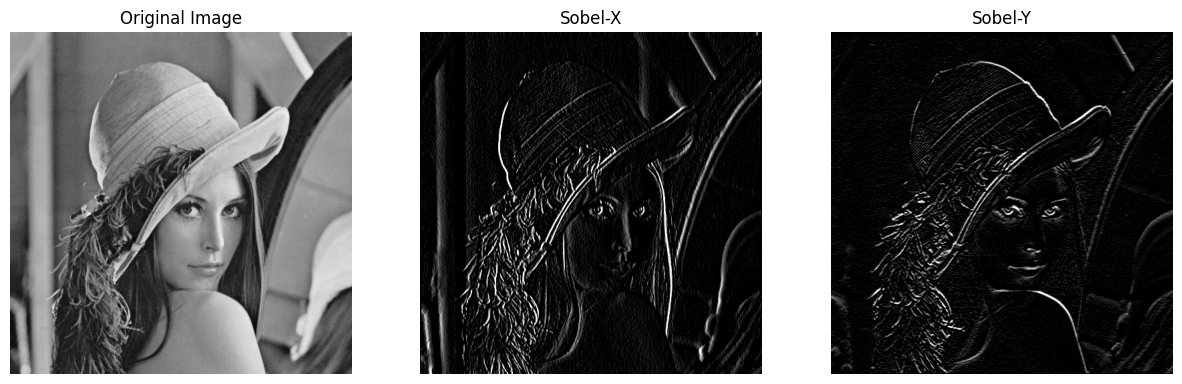

Original 4x4 Matrix:
 [[ 5.  3.  5. 13.]
 [ 4.  8.  2.  8.]
 [10. 14. 16.  2.]
 [ 6. 10.  8. 11.]]

Max-Pooled Matrix (2x2):
 [[ 8. 13.]
 [14. 16.]]

Average-Pooled Matrix (2x2):
 [[ 5.    7.  ]
 [10.    9.25]]


In [10]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import urllib.request
import tensorflow as tf

# --- Image Acquisition and Loading ---
# Retrieve the classic Lena test image directly from GitHub
urllib.request.urlretrieve('https://raw.githubusercontent.com/opencv/opencv/master/samples/data/lena.jpg', 'sample.jpg')
image = cv2.imread('sample.jpg', cv2.IMREAD_GRAYSCALE)

# --- Sobel Kernel Definitions ---
# Sobel filter to detect vertical edges (gradients in X direction)
sobel_x = np.array([[-1, 0, 1], [-2, 0, 2], [-1, 0, 1]], dtype=np.float32)
# Sobel filter to detect horizontal edges (gradients in Y direction)
sobel_y = np.array([[-1, -2, -1], [0, 0, 0], [1, 2, 1]], dtype=np.float32)

# --- 2D Filter Convolutions ---
# Apply the respective kernels to the grayscale image
edge_x = cv2.filter2D(image, -1, sobel_x)
edge_y = cv2.filter2D(image, -1, sobel_y)

# --- Plotting Visual Outputs ---
plt.figure(figsize=(15, 5))
plt.subplot(1, 3, 1)
plt.title('Original Image')
plt.imshow(image, cmap='gray')
plt.axis('off')

plt.subplot(1, 3, 2)
plt.title('Sobel-X')
plt.imshow(edge_x, cmap='gray')
plt.axis('off')

plt.subplot(1, 3, 3)
plt.title('Sobel-Y')
plt.imshow(edge_y, cmap='gray')
plt.axis('off')
plt.show()

# --- Task 2: Pooling Operations ---
# Define a random 4x4 matrix representing simulated activations
random_matrix = np.random.randint(0, 20, size=(4, 4)).astype(np.float32)
print("Original 4x4 Matrix:\n", random_matrix)

# Reshape to a 4D tensor (batch_size=1, height=4, width=4, channels=1)
input_tensor = tf.constant(random_matrix.reshape(1, 4, 4, 1))

# Max Pooling: extracts maximum values in 2x2 windows with stride of 2
max_pool = tf.nn.max_pool2d(input_tensor, ksize=2, strides=2, padding='VALID')

# Average Pooling: extracts averages in 2x2 windows with stride of 2
avg_pool = tf.nn.avg_pool2d(input_tensor, ksize=2, strides=2, padding='VALID')

print("\nMax-Pooled Matrix (2x2):\n", max_pool[0, :, :, 0].numpy())
print("\nAverage-Pooled Matrix (2x2):\n", avg_pool[0, :, :, 0].numpy())

## Question 5: CNN Architectures

In [11]:
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, Input, Add, ReLU

# --- Task 1: Classical AlexNet Architecture ---
# Setup sequential architecture representing AlexNet (used for ImageNet)
alexnet = Sequential([
    # Conv1: 96 filters of size 11x11, stride of 4 with ReLU
    Conv2D(96, kernel_size=(11,11), strides=4, activation='relu', input_shape=(227, 227, 3)),
    MaxPooling2D(pool_size=(3,3), strides=2),

    # Conv2: 256 filters, same padding
    Conv2D(256, kernel_size=(5,5), activation='relu', padding='same'),
    MaxPooling2D(pool_size=(3,3), strides=2),

    # Conv3 & Conv4: Stacked convolutional blocks
    Conv2D(384, kernel_size=(3,3), activation='relu', padding='same'),
    Conv2D(384, kernel_size=(3,3), activation='relu', padding='same'),

    # Conv5: Final convolutional block before spatial pooling
    Conv2D(256, kernel_size=(3,3), activation='relu', padding='same'),
    MaxPooling2D(pool_size=(3,3), strides=2),

    # Flattening spatial maps to feed fully connected layers
    Flatten(),
    Dense(4096, activation='relu'),
    Dropout(0.5),
    Dense(4096, activation='relu'),
    Dropout(0.5),

    # Softmax output mapping classes (assumed 10 classes)
    Dense(10, activation='softmax')
])

print("AlexNet Model Summary:")
alexnet.summary()

# --- Task 2: Functional ResNet-like Architecture ---
# Helper module creating a residual layer with skip connections
def residual_block(input_tensor, filters):
    # First convolutional sub-layer with ReLU
    x = Conv2D(filters, kernel_size=(3,3), padding='same', activation='relu')(input_tensor)
    # Second convolutional sub-layer without activation (applied after addition)
    x = Conv2D(filters, kernel_size=(3,3), padding='same')(x)
    # Skip/Identity connection mapping directly
    x = Add()([x, input_tensor])
    x = ReLU()(x)
    return x

# Set up model using functional Keras API
inputs = Input(shape=(64, 64, 3))
# Initial stride-2 Convolution
x = Conv2D(64, kernel_size=(7,7), strides=2, padding='same', activation='relu')(inputs)
# Double residual blocks representing residual feature maps
x = residual_block(x, 64)
x = residual_block(x, 64)
# Classifier head mapping to output neurons
x = Flatten()(x)
x = Dense(128, activation='relu')(x)
outputs = Dense(10, activation='softmax')(x)

resnet_model = Model(inputs, outputs)
print("\nResNet-Like Model Summary:")
resnet_model.summary()

/usr/local/lib/python3.13/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


AlexNet Model Summary:


Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_10 (Conv2D)              │ (None, 55, 55, 96)     │        34,944 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 27, 27, 96)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 27, 27, 256)    │       614,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 13, 13, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_12 (Conv2D)              │ (None, 13, 13, 384)    │       885,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 13, 13, 384)    │     1,327,488 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_14 (Conv2D)              │ (None, 13, 13, 256)    │       884,992 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 6, 6, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 9216)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 4096)           │    37,752,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 4096)           │    16,781,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 10)             │        40,970 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 58,322,314 (222.48 MB)

...

Model: "functional_12"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_8       │ (None, 64, 64, 3) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_15 (Conv2D)  │ (None, 32, 32,    │      9,472 │ input_layer_8[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_16 (Conv2D)  │ (None, 32, 32,    │     36,928 │ conv2d_15[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_17 (Conv2D)  │ (None, 32, 32,    │     36,928 │ conv2d_16[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_2 (Add)         │ (None, 32, 32,    │          0 │ conv2d_17[0][0],  │
│                     │ 64)               │            │ conv2d_15[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_2 (ReLU)      │ (None, 32, 32,    │          0 │ add_2[0][0]       │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_18 (Conv2D)  │ (None, 32, 32,    │     36,928 │ re_lu_2[0][0]     │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_19 (Conv2D)  │ (None, 32, 32,    │     36,928 │ conv2d_18[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_3 (Add)         │ (None, 32, 32,    │          0 │ conv2d_19[0][0],  │
│                     │ 64)               │            │ re_lu_2[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_3 (ReLU)      │ (None, 32, 32,    │          0 │ add_3[0][0]       │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_3 (Flatten) │ (None, 65536)     │          0 │ re_lu_3[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_13 (Dense)    │ (None, 128)       │  8,388,736 │ flatten_3[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_14 (Dense)    │ (None, 10)        │      1,290 │ dense_13[0][0]    │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 8,547,210 (32.61 MB)

 Trainable params: 8,547,210 (32.61 MB)

 Non-trainable params: 0 (0.00 B)